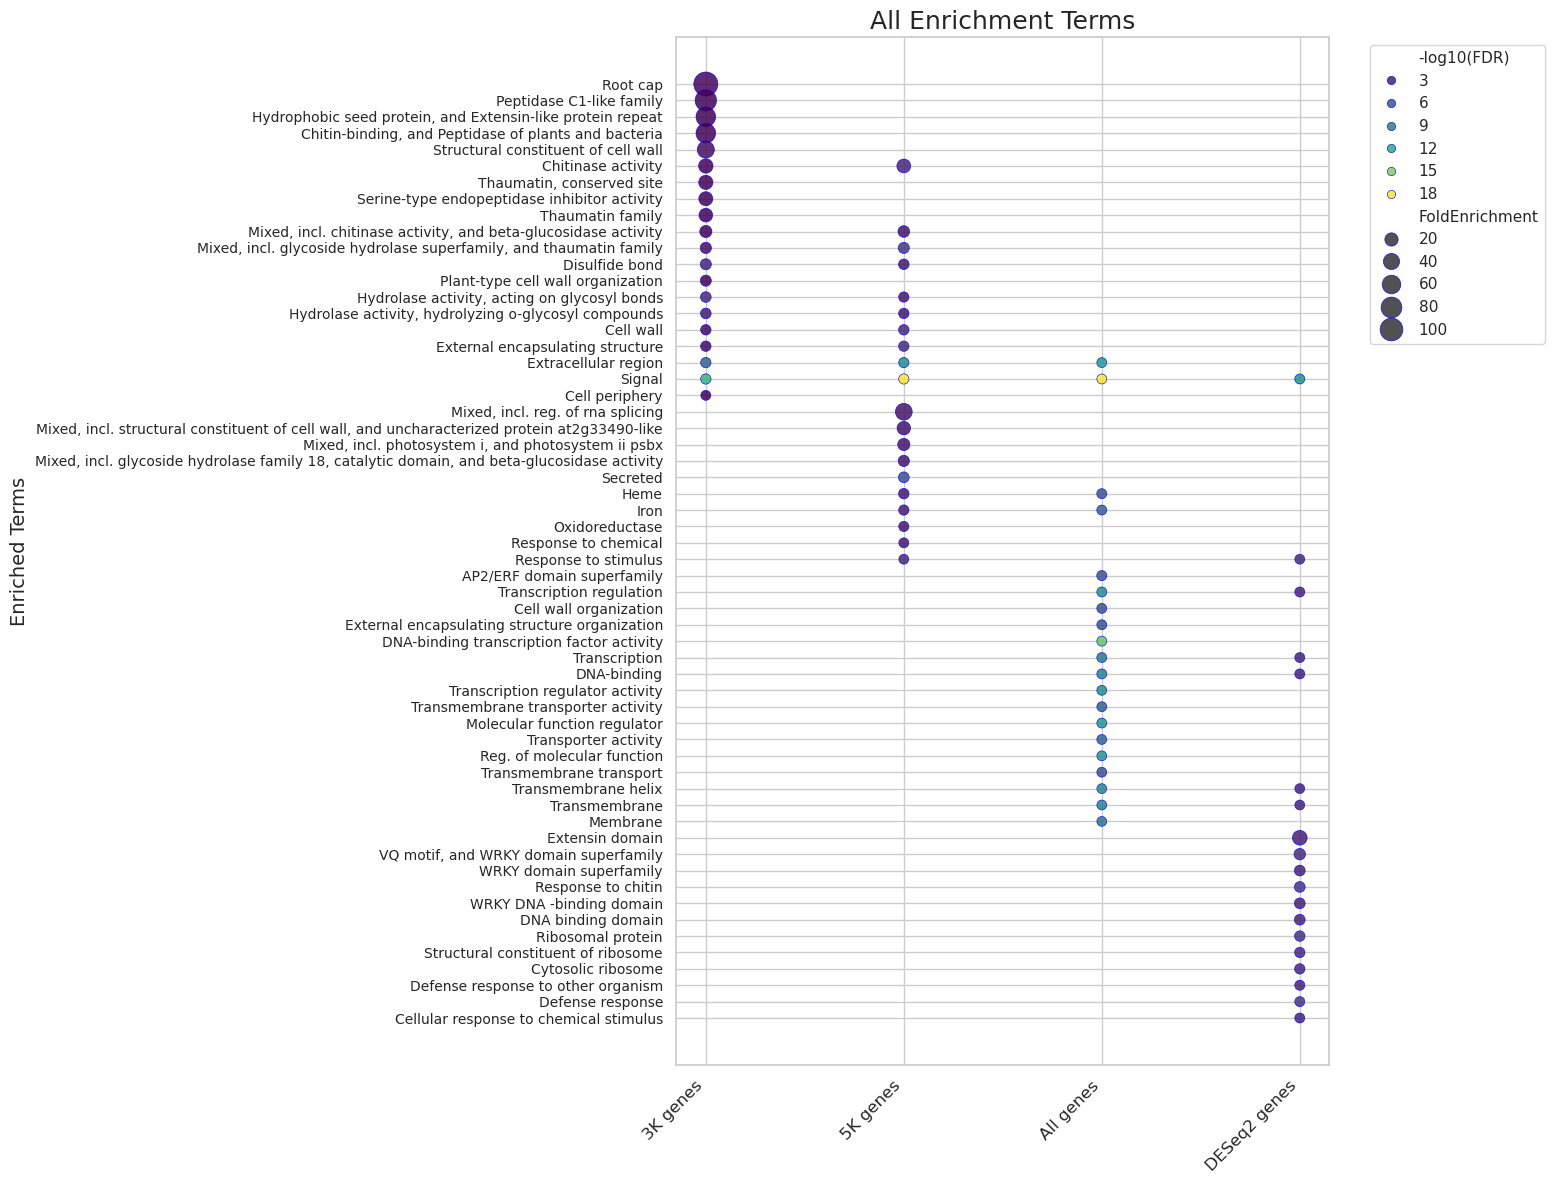

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Updated file map
files = {
    "3K genes": "enrichment (2)_3k.csv",
    "5K genes": "enrichment (2)_5k.csv",
    "All genes": "enrichment (2)_all.csv",
    "DESeq2 genes": "enrichment (2)_deseq2.csv"
}

df_list = []

for label, path in files.items():
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue

    df = pd.read_csv(path)

    # Rename columns if needed
    df = df.rename(columns={
        "Pathway": "Term",
        "Fold Enrichment": "FoldEnrichment",
        "Enrichment FDR": "FDR"
    })

    # Add condition label
    df["Condition"] = label

    df_list.append(df)

# Combine data
df_all = pd.concat(df_list, ignore_index=True)

# Remove missing/invalid values
df_all = df_all.dropna(subset=["Term", "FDR", "FoldEnrichment"])
df_all = df_all[df_all["FDR"] > 0]

# Compute -log10(FDR)
df_all["-log10(FDR)"] = -np.log10(df_all["FDR"])

# Use all terms instead of just top 5
all_terms = df_all.copy()

# Plot
plt.figure(figsize=(16, 12))
sns.set(style="whitegrid")

scatter = sns.scatterplot(
    data=all_terms,
    x="Condition",
    y="Term",
    size="FoldEnrichment",
    hue="-log10(FDR)",
    palette="viridis",
    sizes=(50, 300),
    edgecolor='blue',
    linewidth=0.5,
    alpha=0.85
)

plt.title("All Enrichment Terms", fontsize=18)
plt.xlabel("", fontsize=14)
plt.ylabel("Enriched Terms", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save
plt.savefig("all_fold_enrichments.svg", format="svg", dpi=300)
plt.savefig("all_fold_enrichments.png", format="png", dpi=300)

plt.show()

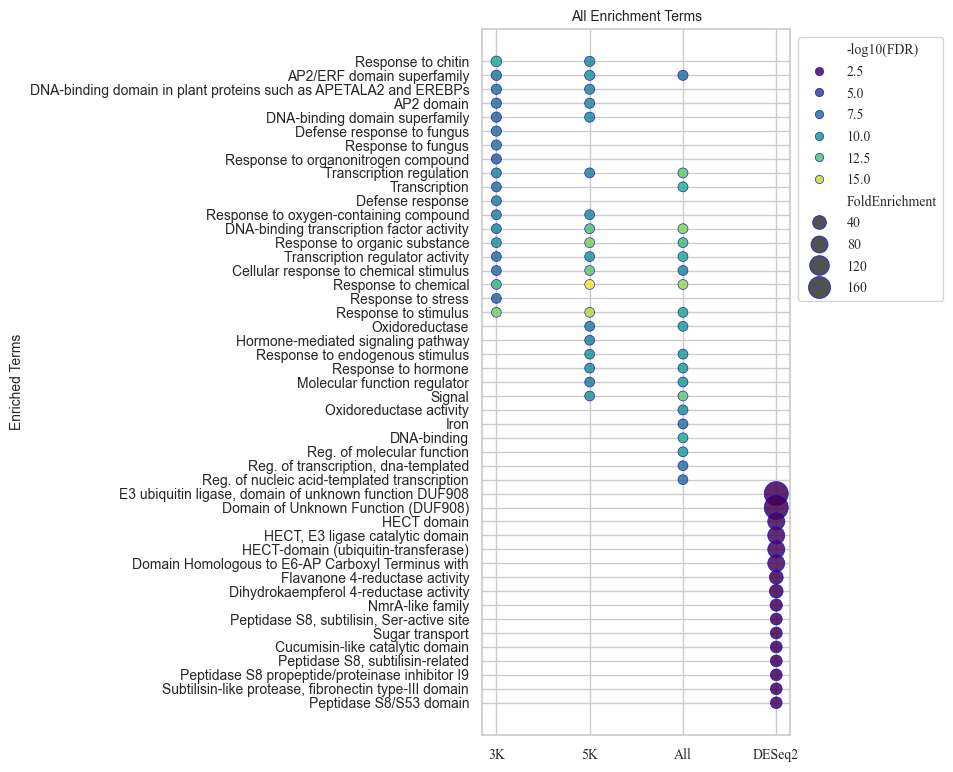

Saved successfully.
Figure size: [6.4 4.8]


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# ===============================
# Font
# ===============================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10


# ===============================
# Files
# ===============================
files = {
    "3K genes": "enrichment (2)_3k.csv",
    "5K genes": "enrichment (2)_5k.csv",
    "All genes": "enrichment (2)_all.csv",
    "DESeq2 genes": "enrichment (2)_deseq2.csv"
}



# ===============================
# Load
# ===============================
df_list = []

for label, path in files.items():

    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue

    df = pd.read_csv(path)

    df = df.rename(columns={
        "Pathway": "Term",
        "Fold Enrichment": "FoldEnrichment",
        "Enrichment FDR": "FDR"
    })

    df["Condition"] = label

    df_list.append(df)


if len(df_list) == 0:
    raise FileNotFoundError("No CSV files loaded. Check paths.")


df_all = pd.concat(df_list, ignore_index=True)


# ===============================
# Clean
# ===============================
df_all = df_all.dropna(subset=["Term", "FDR", "FoldEnrichment"])
df_all = df_all[df_all["FDR"] > 0]

df_all["-log10(FDR)"] = -np.log10(df_all["FDR"])


# ===============================
# Enforce Category Order (KEY STEP)
# ===============================
order = ["3K genes", "5K genes", "All genes", "DESeq2 genes"]

df_all["Condition"] = pd.Categorical(
    df_all["Condition"],
    categories=order,
    ordered=True
)


# ===============================
# Plot
# ===============================
plt.figure(figsize=(7.16, 8.5))
sns.set(style="whitegrid")

scatter = sns.scatterplot(

    data=df_all,

    x="Condition",
    y="Term",

    size="FoldEnrichment",
    hue="-log10(FDR)",

    palette="viridis",
    sizes=(50, 300),

    edgecolor="blue",
    linewidth=0.5,
    alpha=0.85
)


# ===============================
# Labels
# ===============================
plt.title("All Enrichment Terms", fontsize=10)
plt.xlabel("")
plt.ylabel("Enriched Terms", fontsize=10)


# ===============================
# Custom Short X Labels
# ===============================
plt.xticks(

    ticks=range(len(order)),

    labels=["3K", "5K", "All", "DESeq2"],

    rotation=0,
    fontsize=10,
    fontfamily="Times New Roman"
)


plt.yticks(fontsize=10)


# ===============================
# Legend
# ===============================
legend = plt.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=True
)

for text in legend.get_texts():
    text.set_fontfamily("Times New Roman")
    text.set_fontsize(10)

if legend.get_title() is not None:
    legend.get_title().set_fontsize(10)


# ===============================
# Layout (IMPORTANT)
# ===============================
plt.subplots_adjust(
    left=0.35,
    right=0.78,
    bottom=0.10,
    top=0.93
)


# ===============================
# Save
# ===============================
plt.savefig(
    "5K_fold_enrichments_final_seaborn.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "SRR------874_stress_enrichments_final_seaborn.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ===============================
# Info
# ===============================
print("Saved successfully.")
print("Figure size:", plt.gcf().get_size_inches())
